In [1]:
#Import libraries and specify paths

import pandas as pd
import numpy  as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

import shap

import time
import matplotlib.pyplot as plt
import seaborn as sbn
from sklearn.metrics import confusion_matrix

#import pytorch since tensorflow is not supporting in python 3.14
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

torch.manual_seed(42)

print("Librarties imported")

train_csv=r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\UQ-IoT Dataset\Testing and Training CSVs\UQ-IoT_train.csv"
test_csv=r"C:\Users\NARASIMHA N\Documents\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\UQ-IoT Dataset\Testing and Training CSVs\UQ-IoT_test.csv"

print("Paths are set")

Librarties imported
Paths are set


In [2]:
#load train and test data

train_df=pd.read_csv(train_csv)
test_df=pd.read_csv(test_csv)

print(f"Train CSV: {train_df.shape}")
print(f"Test CSV: {test_df.shape}")

print(f"\nTrain label Distribution: {train_df['label'].value_counts().to_dict()}")
print(f"\nTest label Distribution: {test_df['label'].value_counts().to_dict()}")

Train CSV: (24482, 103)
Test CSV: (7061, 103)

Train label Distribution: {0: 12241, 1: 12241}

Test label Distribution: {0: 4000, 1: 3061}


In [3]:
#Separate features and label

feature_columns=[feature for feature in train_df.columns if feature!='label']

X_train=train_df[feature_columns]
y_train=train_df['label']

X_test=test_df[feature_columns]
y_test=test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

X_train shape: (24482, 102)
X_test shape: (7061, 102)
y_train distribution: {0: 12241, 1: 12241}
y_test distribution: {0: 4000, 1: 3061}


In [4]:
#DNN Architecture

class TorchDNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

class DNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42):
        self.epochs=epochs
        self.batch_size=batch_size
        self.lr=lr
        self.patience=patience
        self.random_state=random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)

        X=np.asarray(X, dtype=np.float32)
        y=np.asarray(y, dtype=np.float32).reshape(-1,1)

        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.1, random_state=self.random_state, stratify=y)

        self.model_= TorchDNN(X.shape[1])
        optimizer=torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        loss_function=nn.BCELoss()

        X_tr_t = torch.tensor(X_tr)
        y_tr_t = torch.tensor(y_tr)
        X_val_t = torch.tensor(X_val)
        y_val_t = torch.tensor(y_val)

        best_val_loss = float('inf')
        best_state=None
        epoch_no_improve=0
        n_samples=X_tr_t.shape[0]

        for epoch in range(self.epochs):
            self.model_.train()
            permutation=torch.randperm(n_samples)

            for i in range (0, n_samples, self.batch_size):
                idx=permutation[i : i + self.batch_size]
                batch_X, batch_y = X_tr_t[idx], y_tr_t[idx]

                optimizer.zero_grad()
                outputs=self.model_(batch_X)
                loss=loss_function(outputs, batch_y)
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss=loss_function(self.model_(X_val_t), y_val_t).item()

            if val_loss < best_val_loss:
                best_val_loss=val_loss
                best_state={k: v.clone() for k, v in self.model_.state_dict().items()}
                epoch_no_improve=0
            else:
                epoch_no_improve=epoch_no_improve+1
                if epoch_no_improve >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.classes_=np.array([0,1])
        return self

    def predict_proba(self,X):
        X=np.asarray(X, dtype=np.float32)
        self.model_.eval()
        with torch.no_grad():
            probs=self.model_(torch.tensor(X)).numpy().flatten()
        return np.column_stack([1-probs, probs])

    def predict(self,X):
        probs=self.predict_proba(X)[:,1]
        return (probs>=0.5).astype(int)

# Definition of all models

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42,  probability=True),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'DNN': DNNClassifier(epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42)
}

print("Models Defined:")
for i in models:
    print(i)

Models Defined:
Decision Tree
Random Forest
KNN
SVM
Logistic Regression
XGBoost
DNN


In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cross_validation_results=[]

print("Running 5-fold Cross-validation on training set....")

for model_name, model in models.items():
    print(f"Cross Validating {model_name}....")

    cross_validadtion_scores=cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")

    cross_validation_results.append({
        "Model": model_name,
        "CV Mean F1": round(cross_validadtion_scores.mean(),4),
        "CV Std F1": round(cross_validadtion_scores.std(),4),
        "CV Min F1": round(cross_validadtion_scores.min(),4),
        "CV Max F1": round(cross_validadtion_scores.max(),4)
    })

    print(f"Fold Scores: {[round(s,4) for s in cross_validadtion_scores]}")
    print(f"Mean F1: {cross_validadtion_scores.mean()}")
    print(f"\nStd F1: {cross_validadtion_scores.std()}")

cross_validation_results_df=pd.DataFrame(cross_validation_results)
cross_validation_results_df=cross_validation_results_df.sort_values('CV Mean F1', ascending =False).reset_index(drop=True)
print("Cross Validation Results:\n")
print(cross_validation_results_df.to_string(index=False))

Running 5-fold Cross-validation on training set....
Cross Validating Decision Tree....
Fold Scores: [np.float64(0.9495), np.float64(0.954), np.float64(0.949), np.float64(0.9455), np.float64(0.9591)]
Mean F1: 0.9514081186424251

Std F1: 0.004712234181239418
Cross Validating Random Forest....
Fold Scores: [np.float64(0.9568), np.float64(0.9595), np.float64(0.9575), np.float64(0.9555), np.float64(0.967)]
Mean F1: 0.959255258638889

Std F1: 0.004095469980332649
Cross Validating KNN....
Fold Scores: [np.float64(0.9366), np.float64(0.9423), np.float64(0.9376), np.float64(0.9342), np.float64(0.9427)]
Mean F1: 0.9386746458248153

Std F1: 0.0032937641423686752
Cross Validating SVM....
Fold Scores: [np.float64(0.8652), np.float64(0.8616), np.float64(0.8591), np.float64(0.8632), np.float64(0.8703)]
Mean F1: 0.8638701369689917

Std F1: 0.003791159976365333
Cross Validating Logistic Regression....
Fold Scores: [np.float64(0.8483), np.float64(0.8387), np.float64(0.8475), np.float64(0.8389), np.float

Training Decision Tree....
Model Name: Decision Tree
Accuracy 0.9539725251380824
Precision: 0.9479371316306483
Recall: 0.9457693564194708
F1-Score: 0.946852003270646
Training Time: 2.691761016845703 seconds
Testing Time: 0.014588117599487305 seconds


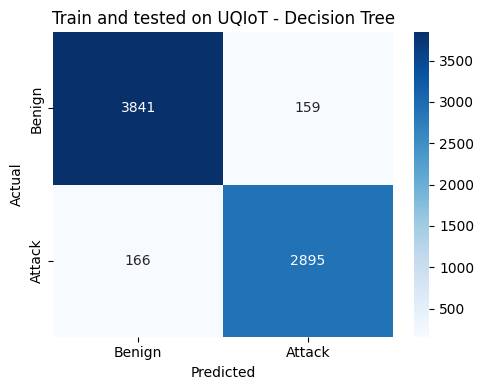

Training Random Forest....
Model Name: Random Forest
Accuracy 0.9634612661096162
Precision: 0.9572593800978793
Recall: 0.9585102907546553
F1-Score: 0.9578844270323212
Training Time: 17.308363914489746 seconds
Testing Time: 0.1496436595916748 seconds


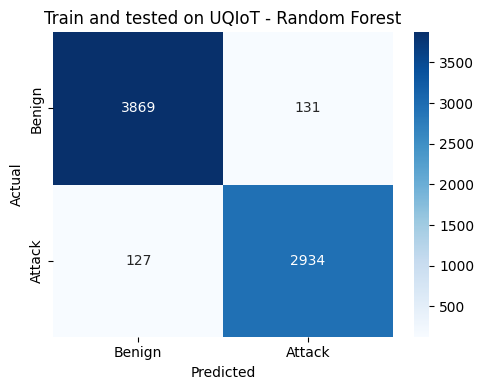

Training KNN....
Model Name: KNN
Accuracy 0.9453335221639995
Precision: 0.9462796129462796
Recall: 0.9264946096047043
F1-Score: 0.9362826015186531
Training Time: 0.03030562400817871 seconds
Testing Time: 1.2927522659301758 seconds


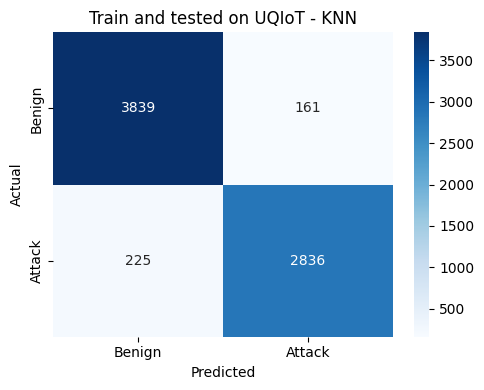

Training SVM....
Model Name: SVM
Accuracy 0.8725393003823821
Precision: 0.9000370233246946
Recall: 0.7941849068931721
F1-Score: 0.8438042346407497
Training Time: 259.28855204582214 seconds
Testing Time: 15.091084718704224 seconds


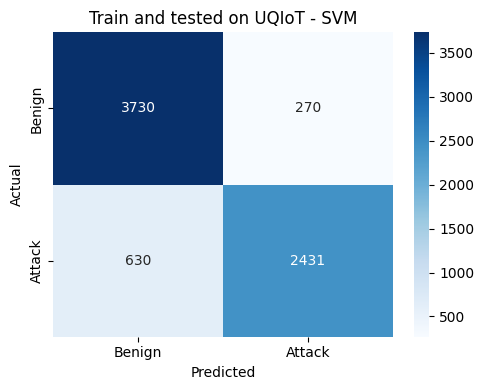

Training Logistic Regression....
Model Name: Logistic Regression
Accuracy 0.8607845914176462
Precision: 0.8897224306076519
Recall: 0.7749101600784057
F1-Score: 0.8283569058844072
Training Time: 3.9564619064331055 seconds
Testing Time: 0.009093761444091797 seconds


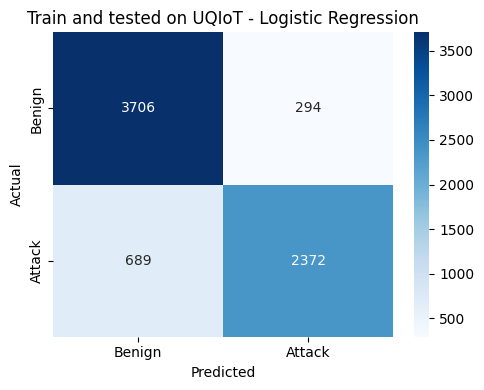

Training XGBoost....
Model Name: XGBoost
Accuracy 0.9636028891091913
Precision: 0.9599737532808399
Recall: 0.9558967657628226
F1-Score: 0.957930921591095
Training Time: 2.6860039234161377 seconds
Testing Time: 0.0226747989654541 seconds


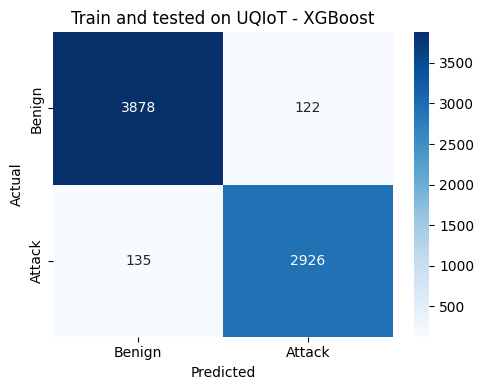

Training DNN....
Model Name: DNN
Accuracy 0.9045460982863617
Precision: 0.9376604327099377
Recall: 0.8353479255145377
F1-Score: 0.8835521769177609
Training Time: 20.03887963294983 seconds
Testing Time: 0.010185718536376953 seconds


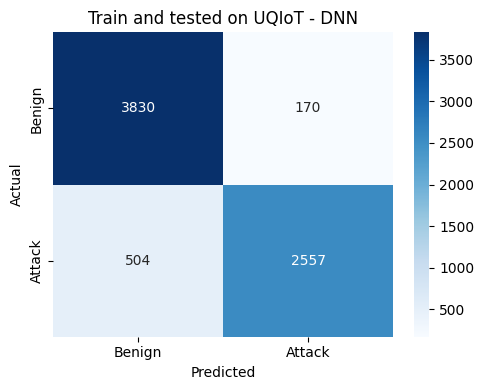


 All models are trained and evaluated


In [6]:
#Train and evaluate all models
import time
results=[]

for model_name, model in models.items():
    print(f"Training {model_name}....")

    #train the model on train data
    start_time=time.time()
    model.fit(X_train, y_train)
    end_time=time.time()
    training_time=end_time-start_time

    #predict on test data
    start_time=time.time()
    y_pred=model.predict(X_test)
    end_time=time.time()
    testing_time=end_time-start_time
    
    #metrics calculation
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)

    #Storing results
    results.append({
         'Model': model_name,
         'Accuracy': round(accuracy,4),
         'Precision': round(precision,4),
         'Recall': round(recall,4),
         'F1-Score': round(f1,4),
         'Training Time (S)': training_time,
         'Testing Time (S)': testing_time
     })
    print(f"Model Name: {model_name}")
    print(f"Accuracy {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"Training Time: {training_time} seconds")
    print(f"Testing Time: {testing_time} seconds")

    #plot confusion matrix,
    cm=confusion_matrix(y_test, y_pred)
    fig,ax=plt.subplots(figsize=(5,4))
    sbn.heatmap(
    cm, annot=True, fmt='d',cmap='Blues',
    xticklabels=['Benign', 'Attack'],
    yticklabels=['Benign', 'Attack'],
    ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"Train and tested on UQIoT - {model_name}")
    plt.tight_layout()
    plt.show()
    plt.close()


print("\n All models are trained and evaluated")       
    

In [7]:
results_df=pd.DataFrame(results)

results_df=results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("UQ-IoT Dataset Model Comparision:")
print(results_df.to_string(index=False))

UQ-IoT Dataset Model Comparision:
              Model  Accuracy  Precision  Recall  F1-Score  Training Time (S)  Testing Time (S)
      Random Forest    0.9635     0.9573  0.9585    0.9579          17.308364          0.149644
            XGBoost    0.9636     0.9600  0.9559    0.9579           2.686004          0.022675
      Decision Tree    0.9540     0.9479  0.9458    0.9469           2.691761          0.014588
                KNN    0.9453     0.9463  0.9265    0.9363           0.030306          1.292752
                DNN    0.9045     0.9377  0.8353    0.8836          20.038880          0.010186
                SVM    0.8725     0.9000  0.7942    0.8438         259.288552         15.091085
Logistic Regression    0.8608     0.8897  0.7749    0.8284           3.956462          0.009094


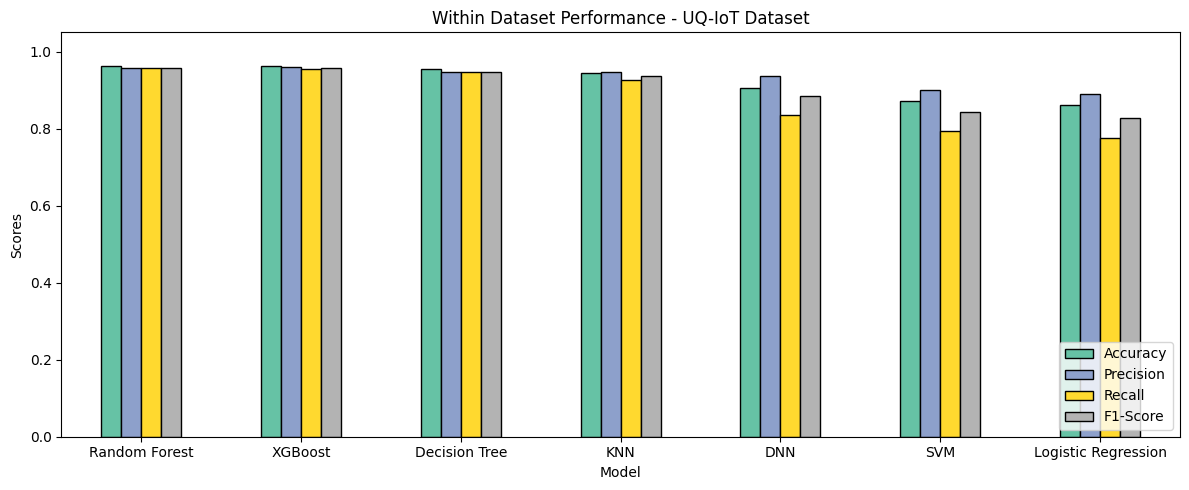

In [8]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].copy()
plot_df = plot_df.apply(pd.to_numeric, errors="coerce")

plot_df.plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Within Dataset Performance - UQ-IoT Dataset")
plt.xlabel("Model")
plt.ylabel("Scores")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [9]:
#SHAP Feature Importance

#as SHAP is very slow on large datasets. A subsample of both train and test set will be taken

train_sample=shap.sample(X_train, 100, random_state=42)

test_sample=X_test.sample(200, random_state=42)

print(f"Train sample shape: {train_sample.shape}")
print(f"Test sample shape: {test_sample.shape}")

Train sample shape: (100, 102)
Test sample shape: (200, 102)


Computing SHAP values for Decision Tree...


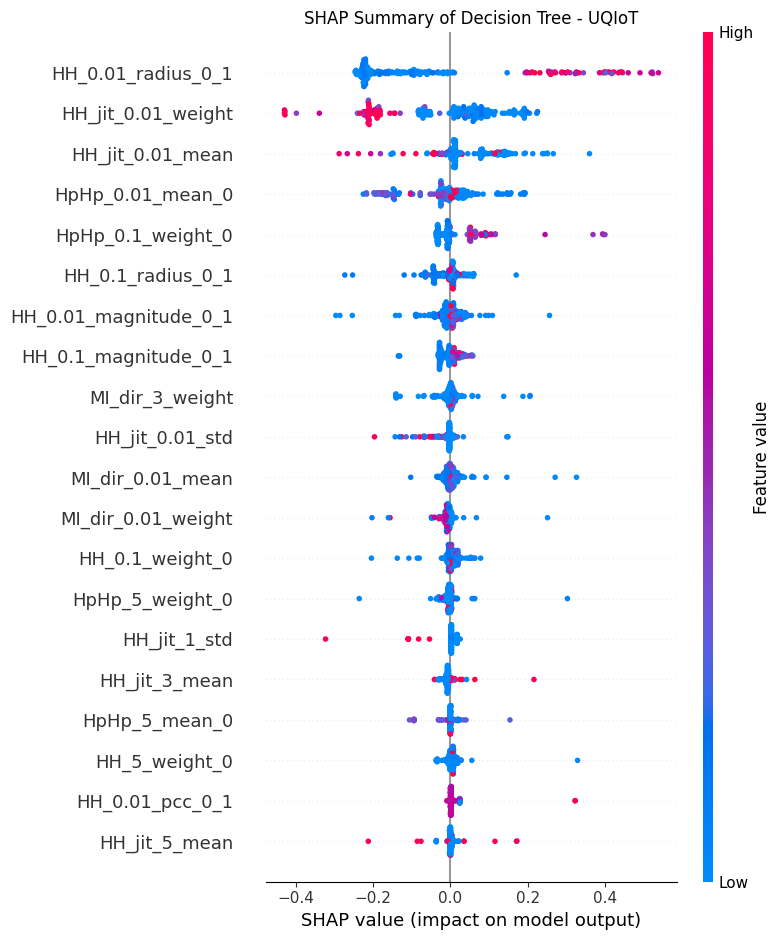

Computing SHAP values for Random Forest...


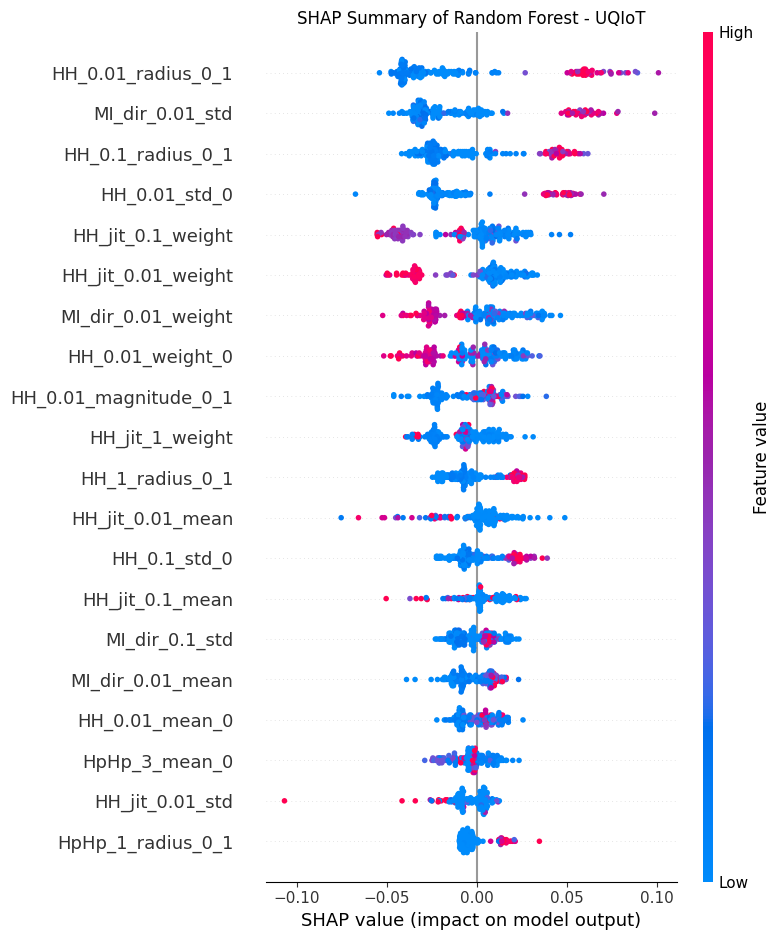

Computing SHAP values for XGBoost...


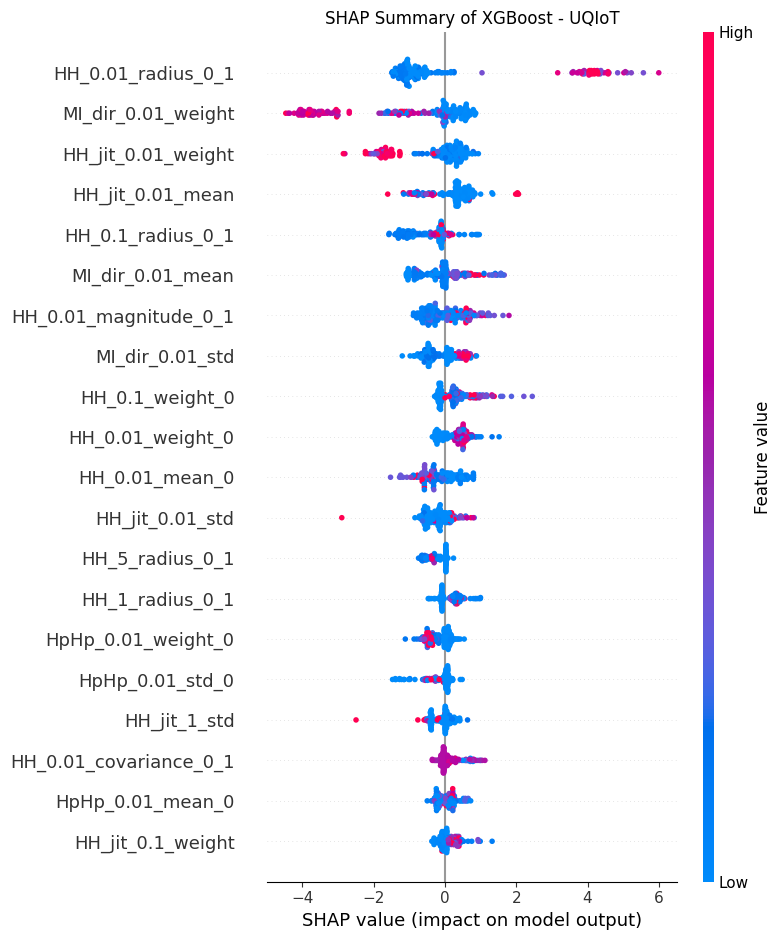

Tree-based SHAP values are calculated

Top 20 features for Decision Tree (UQ-IoT-IDS): 
              Feature  Mean SHAP
   HH_0.01_radius_0_1   0.206639
   HH_jit_0.01_weight   0.118280
     HH_jit_0.01_mean   0.067139
     HpHp_0.01_mean_0   0.060054
    HpHp_0.1_weight_0   0.037010
    HH_0.1_radius_0_1   0.027313
HH_0.01_magnitude_0_1   0.026749
 HH_0.1_magnitude_0_1   0.020407
      MI_dir_3_weight   0.018983
      HH_jit_0.01_std   0.016213
     MI_dir_0.01_mean   0.014716
   MI_dir_0.01_weight   0.013243
      HH_0.1_weight_0   0.012634
      HpHp_5_weight_0   0.010829
         HH_jit_1_std   0.010792
        HH_jit_3_mean   0.010545
        HpHp_5_mean_0   0.010453
        HH_5_weight_0   0.010370
      HH_0.01_pcc_0_1   0.007927
        HH_jit_5_mean   0.007770

Top 20 features for Random Forest (UQ-IoT-IDS): 
              Feature  Mean SHAP
   HH_0.01_radius_0_1   0.038649
      MI_dir_0.01_std   0.030456
    HH_0.1_radius_0_1   0.026119
        HH_0.01_std_0   0.025944
    

In [10]:
#SHAP for tree-based models (Decision Tree, Random Forest and XGBoost)

tree_based_models = ["Decision Tree", "Random Forest", "XGBoost"]
tree_shap_values={}

for model_name in tree_based_models:
    print(f"Computing SHAP values for {model_name}...")
    explainer=shap.TreeExplainer(models[model_name])
    shap_values=explainer.shap_values(test_sample)

    shap_values=np.array(shap_values)
    if shap_values.ndim==3:
        shap_values=shap_values[:,:,1]

    tree_shap_values[model_name]=shap_values

    plt.figure()
    shap.summary_plot(shap_values, test_sample, show=False)
    plt.title(f"SHAP Summary of {model_name} - UQIoT")
    plt.tight_layout()
    plt.show()

print("Tree-based SHAP values are calculated")

tree_imporatnce_table= {}
for model_name, shap_values in tree_shap_values.items():
    mean_abs_shap=np.abs(shap_values).mean(axis=0)
    importance_df=pd.DataFrame({"Feature":test_sample.columns,
                               "Mean SHAP":mean_abs_shap
                               }).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
    tree_imporatnce_table[model_name]=importance_df
    print(f"\nTop 20 features for {model_name} (UQ-IoT-IDS): ")
    print(importance_df.head(20).to_string(index=False))

Background dataset has 24482 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=24482 when initializing the masker.


Computing SHAP values for Logistic Regression...


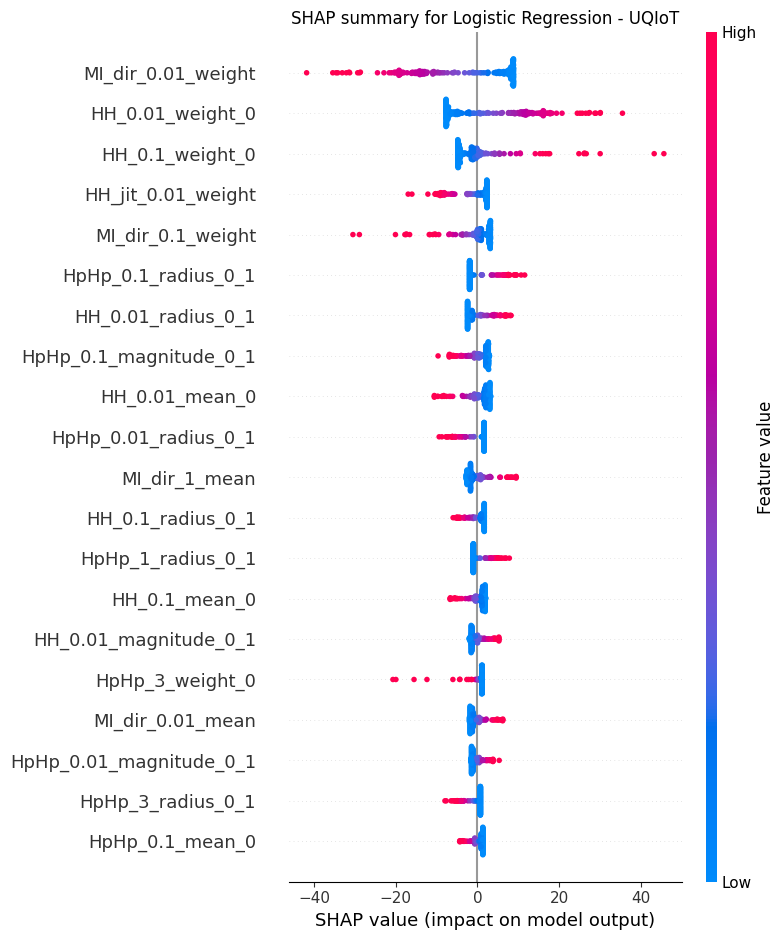


Top 20 features for Logistic Regression (UQ-IoT-IDS):
                Feature  Mean SHAP
     MI_dir_0.01_weight  11.310760
       HH_0.01_weight_0   9.656341
        HH_0.1_weight_0   4.318905
     HH_jit_0.01_weight   3.505461
      MI_dir_0.1_weight   2.869243
    HpHp_0.1_radius_0_1   2.655576
     HH_0.01_radius_0_1   2.461998
 HpHp_0.1_magnitude_0_1   2.413585
         HH_0.01_mean_0   2.356866
   HpHp_0.01_radius_0_1   2.226364
          MI_dir_1_mean   2.120084
      HH_0.1_radius_0_1   1.710608
      HpHp_1_radius_0_1   1.527206
          HH_0.1_mean_0   1.489280
  HH_0.01_magnitude_0_1   1.446776
        HpHp_3_weight_0   1.439099
       MI_dir_0.01_mean   1.422131
HpHp_0.01_magnitude_0_1   1.309941
      HpHp_3_radius_0_1   1.228186
        HpHp_0.1_mean_0   1.175942


In [11]:
#SHAP for Logistic Regression

print("Computing SHAP values for Logistic Regression...")
lr_explainer=shap.LinearExplainer(models['Logistic Regression'], X_train, max_samples=32000)
lr_shap_values=lr_explainer.shap_values(test_sample)

plt.figure()
shap.summary_plot(lr_shap_values, test_sample, show=False)
plt.title("SHAP summary for Logistic Regression - UQIoT")
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(lr_shap_values).mean(axis=0)
lr_importance_df = pd.DataFrame({
    "Feature": test_sample.columns,
    "Mean SHAP": mean_abs_shap
}).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
print("\nTop 20 features for Logistic Regression (UQ-IoT-IDS):")
print(lr_importance_df.head(20).to_string(index=False))

Computing SHAP values for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [49:57<00:00, 59.94s/it]


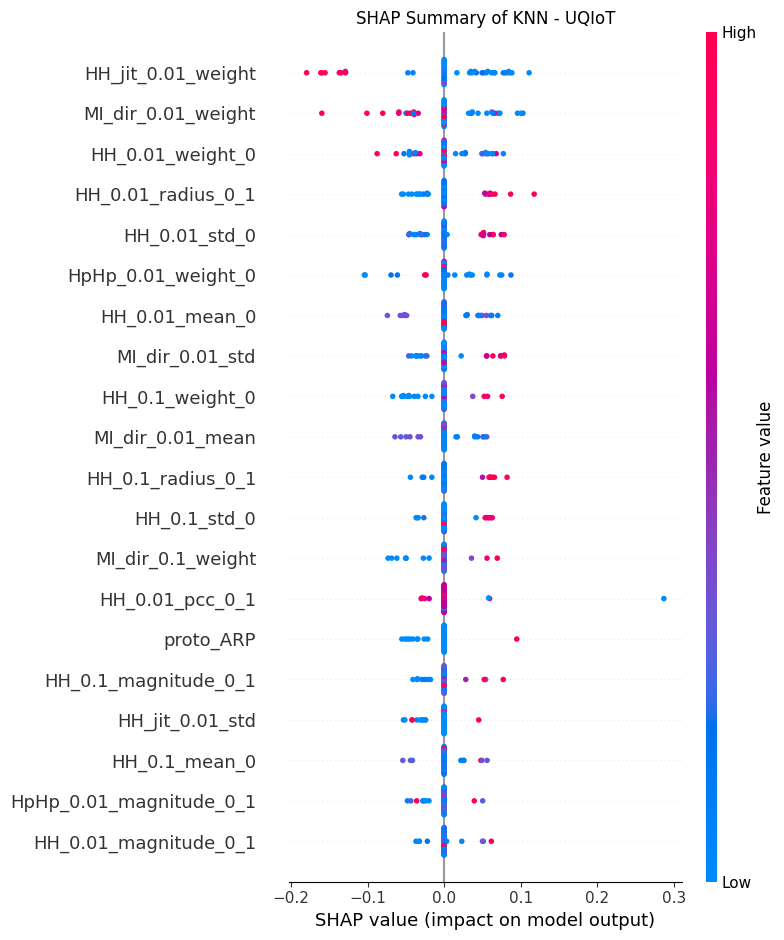

Computing SHAP values for SVM...


100%|███████████████████████████████████████████████████████████████████████████████| 50/50 [7:38:50<00:00, 550.60s/it]


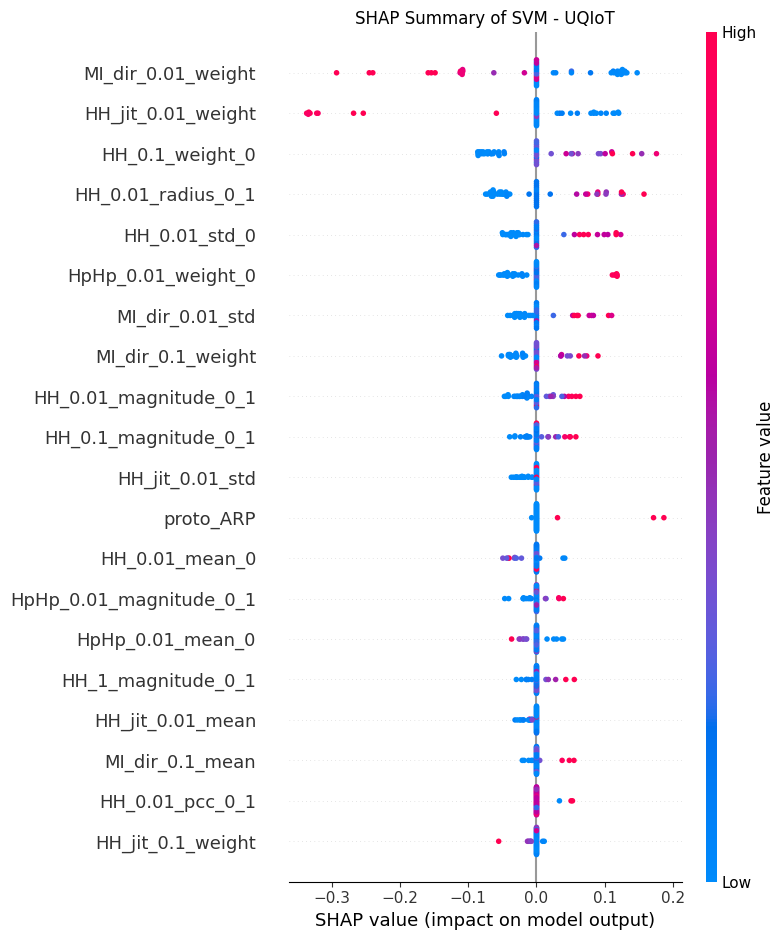

KNN and SVM SHAP values are calculated

Top 20 features for KNN (UQ-IoT-IDS):
                Feature  Mean SHAP
     HH_jit_0.01_weight   0.049812
     MI_dir_0.01_weight   0.033338
       HH_0.01_weight_0   0.025142
     HH_0.01_radius_0_1   0.022013
          HH_0.01_std_0   0.020367
     HpHp_0.01_weight_0   0.017724
         HH_0.01_mean_0   0.017196
        MI_dir_0.01_std   0.016120
        HH_0.1_weight_0   0.015136
       MI_dir_0.01_mean   0.011906
      HH_0.1_radius_0_1   0.011108
           HH_0.1_std_0   0.010454
      MI_dir_0.1_weight   0.010225
        HH_0.01_pcc_0_1   0.010164
              proto_ARP   0.009041
   HH_0.1_magnitude_0_1   0.008307
        HH_jit_0.01_std   0.008106
          HH_0.1_mean_0   0.007317
HpHp_0.01_magnitude_0_1   0.006312
  HH_0.01_magnitude_0_1   0.006262

Top 20 features for SVM (UQ-IoT-IDS):
                Feature  Mean SHAP
     MI_dir_0.01_weight   0.078745
     HH_jit_0.01_weight   0.075320
        HH_0.1_weight_0   0.056546
     HH_

In [12]:
#SHAP for KNN and SVM

kernel_models = ["KNN", "SVM"]
kernel_sample=test_sample.sample(50, random_state=42)
kernel_shap_values = {}

for model_name in kernel_models:
    print(f"Computing SHAP values for {model_name}...")
    model=models[model_name]

    k_explainer=shap.KernelExplainer(model.predict_proba, train_sample)
    shap_values=k_explainer.shap_values(kernel_sample, nsample=100)

    shap_values=np.array(shap_values)
    if shap_values.ndim==3:
        shap_values=shap_values[:,:,1]

    kernel_shap_values[model_name]=shap_values

    plt.figure()
    shap.summary_plot(shap_values, kernel_sample, show=False)
    plt.title(f"SHAP Summary of {model_name} - UQIoT")
    plt.tight_layout()
    plt.show()

print("KNN and SVM SHAP values are calculated")

kernel_importance_tables = {}
for model_name, shap_values in kernel_shap_values.items():
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        "Feature": kernel_sample.columns,
        "Mean SHAP": mean_abs_shap
    }).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
    kernel_importance_tables[model_name] = importance_df
    print(f"\nTop 20 features for {model_name} (UQ-IoT-IDS):")
    print(importance_df.head(20).to_string(index=False))

Computing SHAP values for DNN...


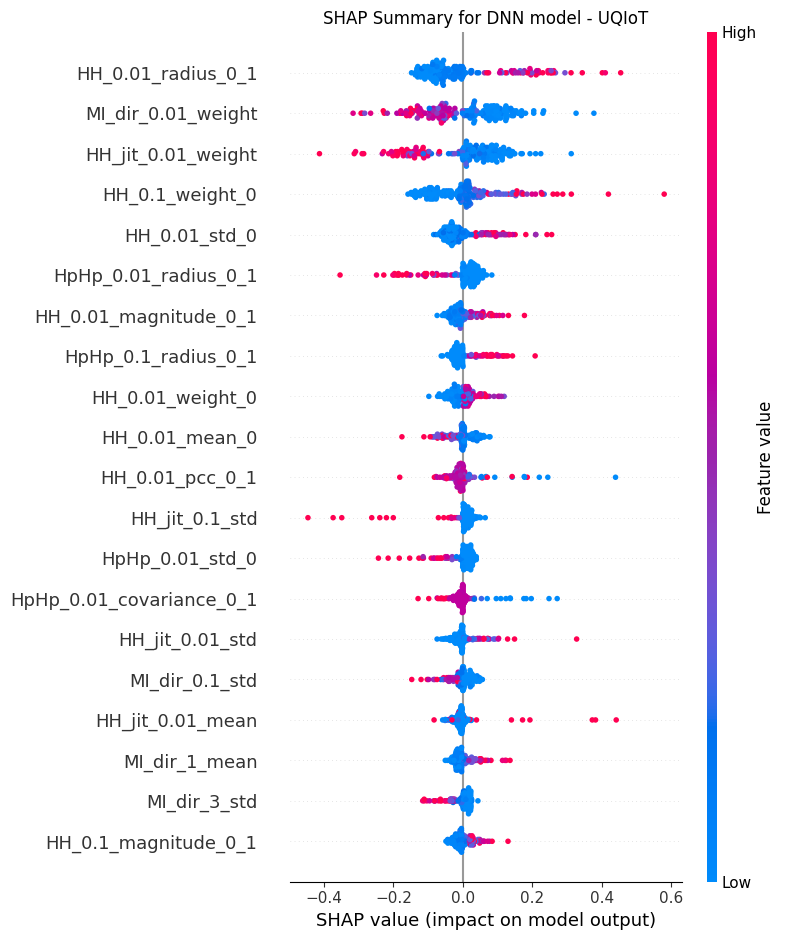

DNN SHAP values are calculated.

Top 20 features for DNN (UQ-IoT-IDS):
                 Feature  Mean SHAP
      HH_0.01_radius_0_1   0.098311
      MI_dir_0.01_weight   0.097175
      HH_jit_0.01_weight   0.093906
         HH_0.1_weight_0   0.073294
           HH_0.01_std_0   0.046814
    HpHp_0.01_radius_0_1   0.043807
   HH_0.01_magnitude_0_1   0.027281
     HpHp_0.1_radius_0_1   0.026331
        HH_0.01_weight_0   0.026143
          HH_0.01_mean_0   0.025714
         HH_0.01_pcc_0_1   0.025014
          HH_jit_0.1_std   0.023998
         HpHp_0.01_std_0   0.023515
HpHp_0.01_covariance_0_1   0.020998
         HH_jit_0.01_std   0.020688
          MI_dir_0.1_std   0.020571
        HH_jit_0.01_mean   0.020190
           MI_dir_1_mean   0.019937
            MI_dir_3_std   0.019191
    HH_0.1_magnitude_0_1   0.019019


In [13]:
#SHAP for DNN model

print("Computing SHAP values for DNN...")

dnn_model=models["DNN"].model_
dnn_model.eval()

train_sample_t=torch.tensor(train_sample.values.astype('float32'))
test_sample_t=torch.tensor(test_sample.values.astype('float32'))

dnn_explainer=shap.GradientExplainer(dnn_model, test_sample_t)
dnn_shap_values=dnn_explainer.shap_values(test_sample_t)

if isinstance(dnn_shap_values, list):
    dnn_shap_values=dnn_shap_values[0]

dnn_shap_values=np.squeeze(dnn_shap_values)

plt.figure()
shap.summary_plot(dnn_shap_values, test_sample, show=False)
plt.title("SHAP Summary for DNN model - UQIoT")
plt.tight_layout()
plt.show()

print("DNN SHAP values are calculated.")

mean_abs_shap = np.abs(dnn_shap_values).mean(axis=0)
dnn_importance_df = pd.DataFrame({
    "Feature": test_sample.columns,
    "Mean SHAP": mean_abs_shap
}).sort_values("Mean SHAP", ascending=False).reset_index(drop=True)
print("\nTop 20 features for DNN (UQ-IoT-IDS):")
print(dnn_importance_df.head(20).to_string(index=False))

In [14]:
# Combine top-20 feature sets from all 7 models and print the common (intersection) features
all_top20 = {}

for model_name, df in tree_imporatnce_table.items():
    all_top20[model_name] = set(df["Feature"].head(20))

all_top20["Logistic Regression"] = set(lr_importance_df["Feature"].head(20))

for model_name, df in kernel_importance_tables.items():
    all_top20[model_name] = set(df["Feature"].head(20))

all_top20["DNN"] = set(dnn_importance_df["Feature"].head(20))

print(f"Models included in intersection: {list(all_top20.keys())}\n")

common_features = set.intersection(*all_top20.values())
print(f"Features in top20 across all {len(all_top20)} models are: {common_features}")

# How many of the models each feature appears in (if the above intersection is empty or very small)
from collections import Counter
feature_counts = Counter()
for features in all_top20.values():
    for f in features:
        feature_counts[f] += 1

coverage_df = pd.DataFrame(
    feature_counts.most_common(),
    columns=["Feature", "Models".format(len(all_top20))]
)
print("\nFeature coverage across all models (UQ-IoT-IDS), most consistent first:")
print(coverage_df.to_string(index=False))

Models included in intersection: ['Decision Tree', 'Random Forest', 'XGBoost', 'Logistic Regression', 'KNN', 'SVM', 'DNN']

Features in top20 across all 7 models are: {'HH_0.01_radius_0_1', 'HH_jit_0.01_weight', 'MI_dir_0.01_weight', 'HH_0.01_magnitude_0_1'}

Feature coverage across all models (UQ-IoT-IDS), most consistent first:
                 Feature  Models
      MI_dir_0.01_weight       7
      HH_0.01_radius_0_1       7
   HH_0.01_magnitude_0_1       7
      HH_jit_0.01_weight       7
         HH_0.1_weight_0       6
         HH_jit_0.01_std       6
          HH_0.01_mean_0       6
        HH_jit_0.01_mean       5
        MI_dir_0.01_mean       5
       HH_0.1_radius_0_1       5
        HH_0.01_weight_0       5
    HH_0.1_magnitude_0_1       4
         HH_0.01_pcc_0_1       4
           HH_0.01_std_0       4
         MI_dir_0.01_std       4
        HpHp_0.01_mean_0       3
       HH_jit_0.1_weight       3
      HpHp_0.01_weight_0       3
       MI_dir_0.1_weight       3
 HpHp_0.